In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Lecture 17

## The GTA's Defense

In [2]:
# Read in data for entire class scores on the midterm 
#  each row is a person with their section and midterm score
scores = Table.read_table('scores_by_section.csv')
scores

Section,Midterm
1,22
2,12
2,23
2,14
1,20
3,25
4,19
1,24
5,8
6,14


In [3]:
# Show the number of students in each Section 
scores.group('Section')

Section,count
1,32
2,32
3,27
4,30
5,33
6,32
7,24
8,29
9,30
10,34


In [4]:
# Calculate the average score in each Section
scores.group('Section', np.average).show()

Section,Midterm average
1,15.5938
2,15.125
3,13.6667
4,14.7667
5,17.4545
6,15.0312
7,16.625
8,16.3103
9,14.5667
10,15.2353


**Q: What do you observe? **

* Section 3 is the lowest average
* Section 5 is the highest
* The average looks to be 15.5

In [5]:
np.average(scores.column('Midterm'))

15.493036211699165

Store the observed average for section 3, we will use this to compare to the simulations. 

In [6]:
# Specify the average score in the section in question, Section 3 
observed_average = 13.6667 

In [7]:
# Create a single random sample 
#  What should the sample size be?  
random_sample = scores.sample(27, with_replacement=False)
random_sample

Section,Midterm
4,12
9,4
10,7
1,21
1,14
6,13
12,18
1,11
10,21
6,10


In [8]:
# Calculate average score for the random sample 
np.average(random_sample.column('Midterm'))

15.37037037037037

Make a function that will: 
 - simulate a  single random sample,
 - then calculate the test statistic, the average of the scores
 - and return this value

In [9]:
# Simulate one value of the test statistic 
# under the hypothesis that the section is like a random sample from the class

def random_sample_midterm_avg():
    random_sample = scores.sample(27, with_replacement = False)
    return np.average(random_sample.column('Midterm'))

In [10]:
# Simulate 50,000 copies of the test statistic

sample_averages = make_array()

for i in np.arange(50000):
    sample_averages = np.append(sample_averages, random_sample_midterm_avg())    

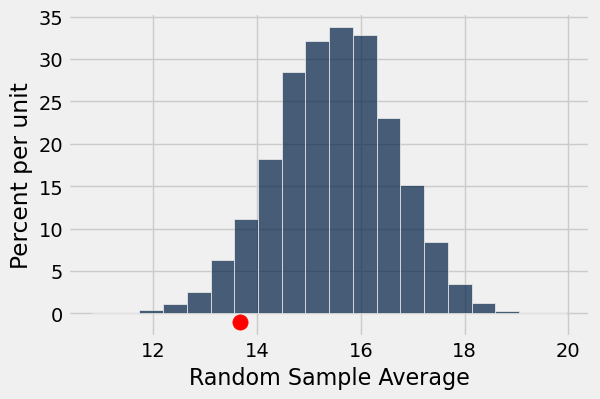

In [11]:
# Compare the simulated distribution of the statistic
# and the actual observed statistic
averages_tbl = Table().with_column('Random Sample Average', sample_averages)
averages_tbl.hist(bins = 20)
plots.scatter(observed_average, -0.01, color='red', s=120);

This is the first example we have seen where the observed value is in a questionable region of the histogram. 

- It is not clearly above or below the histogram (as we saw with the first jury selection problem)
- It is not near the middle (as we saw with Mendel's pea plants)

In this case, it seems like it may be consistent with the model simulations, but also on the edge (somewhat rare).  **How do we make a decision?** 

**Q** Who thinks the data is consistent with the model?  
Who thinks the data is consistent with the alternative? 

We want to come up with a rule or well-defined way to make these conclusions. 

<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>

## Conventions About Inconsistency

Today we are going to use the 5% threshold. 

### Approach 1

The number of simulations less than or equal to the observed statistic, then divide by the total number of simulations. 

In [12]:
# (1) Calculate the p-value: simulation area beyond observed value
np.count_nonzero(sample_averages <= observed_average) / 50000
# (2) See if this is less than 5%

0.05776

The area to the left of the observed value is 5.74%. 

With our threshold of 5%, this is not quite small enough to say that this is a super rare thing. 



### Approach 2

Alternative problem.  Instead of calculating what percentage of the simulations is to the left of the observed value. 

Instead frame the problem as what value along the x-axis of the histogram is such that 5% is to the left of it? 

In [13]:
# (1) Find simulated value corresponding to 5% of 50,000 = 2500
five_percent_point = averages_tbl.sort(0).column(0).item(2500)
five_percent_point

13.592592592592593

In [14]:
# (2) See if this value is greater than observed value
observed_average

13.6667

### Visual Representation

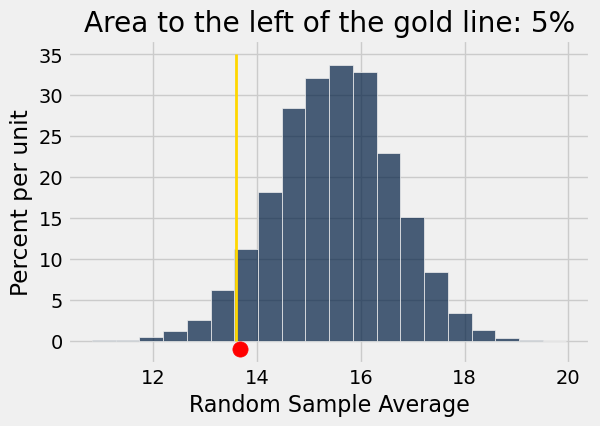

In [15]:
averages_tbl.hist(bins = 20)
plots.plot([five_percent_point, five_percent_point], [0, 0.35], color='gold', lw=2)
plots.title('Area to the left of the gold line: 5%');
plots.scatter(observed_average, -0.01, color='red', s=120);

The point is just to the right of the gold bar so we are going to stay with the null hypothesis. 

<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>